In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")  # Change to "gpu" if running on a cluster
import jax.numpy as jnp
print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX devices: [CpuDevice(id=0)]
Default backend: cpu


In [2]:
import numpy as np
from functools import partial
import matplotlib.pyplot as plt
import healpy as hp
from healpy import get_nside, projview, ud_grade, Alm

import croissant as cro
import croissant.jax as crojax
import lunarsky
import s2fft
import astropy
import astropy.units as u

import time
import itertools
from tqdm.notebook import tqdm
from concurrent.futures import ProcessPoolExecutor

# MCMC Imports
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import corner  # pip install corner (for the posterior plots)

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [3]:
def create_perturbed_base_map(base_pixel_map, lmax, nside, amp_scale=1.10, phase_shift_deg=5.0):
    """
    Takes a 1D pixel map, converts it to 2D s2fft ALMs, applies a 
    consistent phase/amplitude perturbation, and returns the modified pixel map.
    """
    # Forward SHT to get into 2D s2fft ALM space
    beam2alm = partial(s2fft.forward_jax, L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True)
    clean_alms = beam2alm(jnp.array(base_pixel_map))
    
    # Apply the complex phase and amplitude shift
    phase_rad = np.radians(phase_shift_deg)
    perturbation_factor = amp_scale * np.exp(1j * phase_rad)
    perturbed_alms = clean_alms * perturbation_factor
    
    # Inverse SHT to turn it back into a valid HEALPix pixel map
    alm2beam = partial(s2fft.inverse_jax, L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True)
    perturbed_map = alm2beam(perturbed_alms).real
    
    return np.asarray(perturbed_map)

def rotate_bowtie(bowtie_beam, elaz):
    el, az = elaz
    angle_1 = (0, 0, el)
    angle_2 = (az, 0, 0)
    rotator_1 = hp.rotator.Rotator(rot=angle_1)
    rotator_2 = hp.rotator.Rotator(rot=angle_2)
    rotator = rotator_1 * rotator_2
    rotated_bowtie_beam = np.empty(bowtie_beam.shape)
    for i, beam in enumerate(bowtie_beam):
        rotated_bowtie_beam[i] = rotator.rotate_map_alms(beam)
    return rotated_bowtie_beam

# Load Beams
bowtie = np.load('eigsep_bowtie_v000.npz')
vivaldi = np.load('eigsep_vivaldi.npz')

# SVD the bowtie beam (full_matrices=False saves ~19 GB of RAM!)
u_svd, s_svd, v_svd = np.linalg.svd(bowtie['bm'], full_matrices=False)
print(f"SVD computed safely! U shape: {u_svd.shape}, V shape: {v_svd.shape}")

# Frequency Indices
FREQ_START = 6
FREQ_END = 7
N_FREQS = FREQ_END - FREQ_START
freq = vivaldi['freqs'][FREQ_START:FREQ_END]
nside = vivaldi['nside'].item()
lmax = 2 * nside
npix = bowtie['bm'].shape[-1]

# --- CREATE THE PERTURBED BASE MAP WITH POWER CONSERVATION ---
base_bowtie_multi_TRUE = bowtie['bm'][FREQ_START:FREQ_END]
base_bowtie_multi_PERTURBED = np.zeros_like(base_bowtie_multi_TRUE)

# We need the true total power to anchor our normalization
beam2alm = partial(s2fft.forward_jax, L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True)

for f in range(N_FREQS):
    # 1. Calculate the total power (norm) of the clean base beam
    clean_alms = beam2alm(jnp.array(base_bowtie_multi_TRUE[f]))
    true_power = crojax.alm.total_power(clean_alms, lmax)
    
    # 2. Generate the raw perturbed map (introduces the 5-degree phase warp)
    raw_perturbed_map = create_perturbed_base_map(
        base_bowtie_multi_TRUE[f], 
        lmax, 
        nside, 
        amp_scale=1.10,         # Keeps your 10% amplitude structure
        phase_shift_deg=5.0     # Keeps your 5-degree phase distortion
    )
    
    # 3. Calculate the power of this new perturbed map
    perturbed_alms_raw = beam2alm(jnp.array(raw_perturbed_map))
    perturbed_power_raw = crojax.alm.total_power(perturbed_alms_raw, lmax)
    
    # 4. Enforce power conservation! 
    # Scale the map so its total integrated power exactly matches the true universe beam
    u_scale = jnp.sqrt(true_power / perturbed_power_raw)
    base_bowtie_multi_PERTURBED[f] = raw_perturbed_map * u_scale

print("Power-conserving perturbed base beam created successfully!")
# =====================================================================

SVD computed safely! U shape: (202, 202), V shape: (202, 49152)
Power-conserving perturbed base beam created successfully!


In [4]:
# --- ROTATE BOTH THROUGH THE 20 POINTINGS ---
elaz_pointings = [(float(el), 0.0) for el in np.linspace(0, 90, 20)]

rotated_bowties_TRUE = []
rotated_bowties_PERTURBED = []

for elaz in tqdm(elaz_pointings, desc="Rotating beams"):
    # 1. Rotate the clean base beam across all 20 pointings
    rotated_bowties_TRUE.append(rotate_bowtie(base_bowtie_multi_TRUE, elaz))
    
    # 2. Rotate the flawed base beam across the exact same 20 pointings
    # Every single pointing now inherits the exact same physical distortion!
    rotated_bowties_PERTURBED.append(rotate_bowtie(base_bowtie_multi_PERTURBED, elaz))

# Combine and mask the back-lobes (npix//2)
beams_true_f = jnp.array(np.stack(rotated_bowties_TRUE)).at[..., npix//2:].set(0)
beams_pert_f = jnp.array(np.stack(rotated_bowties_PERTURBED)).at[..., npix//2:].set(0)

# --- FINAL STEP: RUN SHT TO GET YOUR DOWNSTREAM ARRAYS ---
beam_alms_TRUE = []
beam_alms_PERTURBED = []
norms_TRUE = []
norms_PERTURBED = []

beam2alm = partial(s2fft.forward_jax, L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True)

for b_idx in tqdm(range(beams_true_f.shape[0]), desc="Final SHT on Beams"):
    # SHT and Norms on True (for generating y_true data)
    alm_t = jax.vmap(beam2alm)(beams_true_f[b_idx])
    norm_t = jax.vmap(lambda x: crojax.alm.total_power(x, lmax))(alm_t)
    
    # SHT and Norms on Perturbed (for your Wiener Filter / MCMC guesses)
    alm_p = jax.vmap(beam2alm)(beams_pert_f[b_idx])
    norm_p = jax.vmap(lambda x: crojax.alm.total_power(x, lmax))(alm_p)
    
    beam_alms_TRUE.append(alm_t)
    beam_alms_PERTURBED.append(alm_p)
    norms_TRUE.append(norm_t)
    norms_PERTURBED.append(norm_p)

# Convert to final JAX Tensors
beam_alms_TRUE = jnp.array(beam_alms_TRUE)          # Shape: (B, F, L, M)
beam_alms_PERTURBED = jnp.array(beam_alms_PERTURBED)  # Shape: (B, F, L, M)
norms_TRUE = jnp.array(norms_TRUE)                  # Shape: (B, F)
norms_PERTURBED = jnp.array(norms_PERTURBED)          # Shape: (B, F)

Rotating beams:   0%|          | 0/20 [00:00<?, ?it/s]

Final SHT on Beams:   0%|          | 0/20 [00:00<?, ?it/s]

take beam_alms, change amplitudes/phase in some random way(1%, 10%) -> eventually should be able to start with any random guess for beam

In [5]:
ntimes = 500
world = "earth"

dt_sim = cro.constants.sidereal_day[world] / ntimes
phases = crojax.simulator.rot_alm_z(lmax, ntimes, dt_sim, world=world)

time_obs = astropy.time.Time("2025-12-01 09:00:00")
loc = astropy.coordinates.EarthLocation(lat=39.2477, lon=-113.4033)
topo = astropy.coordinates.AltAz(obstime=time_obs, location=loc)

eul_topo, dl_topo = crojax.rotations.generate_euler_dl(lmax, topo, "fk5")
eul_gal, dl_gal = crojax.rotations.generate_euler_dl(lmax, "galactic", "fk5")

topo2fk5 = partial(s2fft.utils.rotation.rotate_flms, L=lmax+1, rotation=eul_topo, dl_array=dl_topo)
gal2fk5 = partial(s2fft.utils.rotation.rotate_flms, L=lmax+1, rotation=eul_gal, dl_array=dl_gal)

def load_true_sky(realistic=False):
    sky_L = lmax + 1
    sky_nside = sky_L // 2  
    if realistic:
        # Load the full map from disk, but slice to the selected frequency batch immediately
        sky_map = np.load("gsm_model.npy")[FREQ_START:FREQ_END]
        original_nside = get_nside(sky_map[0]) 
        if sky_nside != original_nside:
            sky_map = ud_grade(sky_map, sky_nside)
        sky_map = jnp.array(sky_map)
        sky2alm = partial(s2fft.forward_jax, L=sky_L, spin=0, nside=sky_nside, sampling="healpix", reality=True)
        sky_alm = jax.vmap(sky2alm)(sky_map) 
        sky_alm = jax.vmap(gal2fk5)(sky_alm)
        return sky_alm
    else:
        return jnp.zeros((N_FREQS, lmax+1, 2*lmax+1), dtype=jnp.complex128)

# Load the true celestial sky for our specific frequency batch
true_sky_alm = load_true_sky(realistic=True)


# =====================================================================
# ROTATE BOTH TRUE AND PERTURBED BEAMS TO FK5
# =====================================================================

# 1. Rotate the TRUE beams to FK5 (Used downstream to generate y_true)
beam_alms_TRUE_transformed = []
for b_idx in tqdm(range(beam_alms_TRUE.shape[0]), desc="Rotating True Beams to FK5"):
    beam_alm_rot = jax.vmap(topo2fk5)(beam_alms_TRUE[b_idx]) # vmap across Freqs
    beam_alms_TRUE_transformed.append(beam_alm_rot)
beam_alms_TRUE_transformed = jnp.array(beam_alms_TRUE_transformed) # (B, F, L, M)


# 2. Rotate the PERTURBED starting guess beams to FK5 (Used in Wiener Filter / MCMC)
beam_alms_PERTURBED_transformed = []
for b_idx in tqdm(range(beam_alms_PERTURBED.shape[0]), desc="Rotating Perturbed Beams to FK5"):
    beam_alm_rot = jax.vmap(topo2fk5)(beam_alms_PERTURBED[b_idx]) # vmap across Freqs
    beam_alms_PERTURBED_transformed.append(beam_alm_rot)
beam_alms_PERTURBED_transformed = jnp.array(beam_alms_PERTURBED_transformed) # (B, F, L, M)


# Clean up unneeded instrument-frame variables to free RAM
del beam_alms_TRUE, beam_alms_PERTURBED

Rotating True Beams to FK5:   0%|          | 0/20 [00:00<?, ?it/s]

Rotating Perturbed Beams to FK5:   0%|          | 0/20 [00:00<?, ?it/s]

--- Visualizing ROTATED Starting Beams (Pointing 0, Freq Index 6) ---


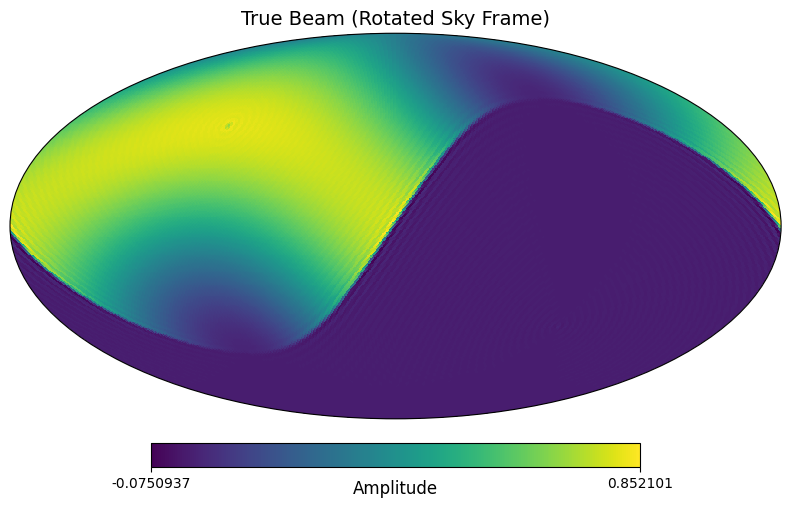

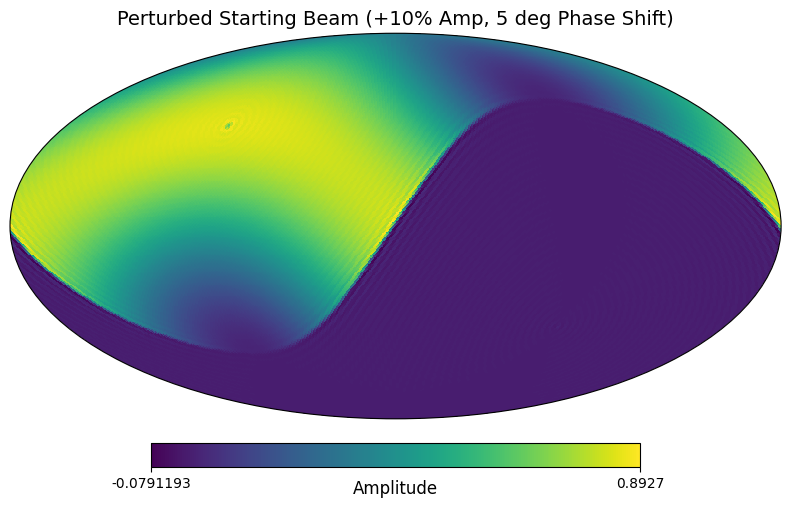

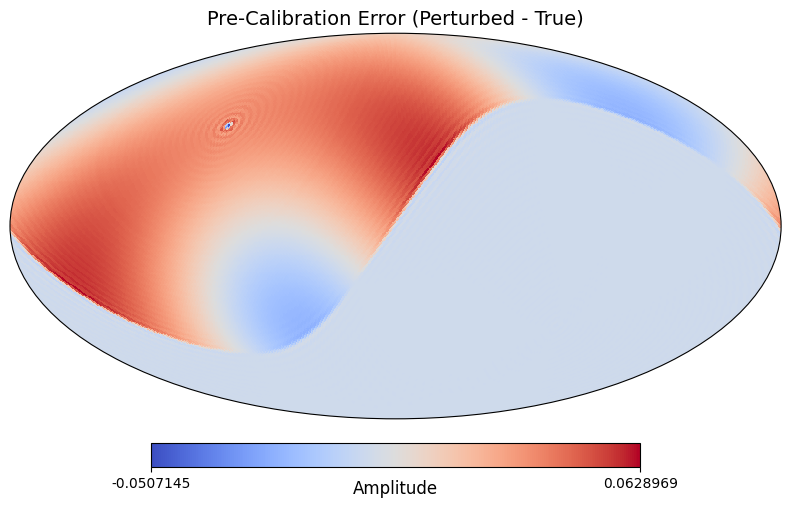

In [6]:
# 1. Choose which pointing and frequency to look at
b_idx = 0  # First pointing angle
f_idx = 0  # First frequency channel in your batch

# 2. Extract the maps IN THE ROTATED SKY FRAME via Inverse SHT
true_beam_pixel = s2fft.inverse_jax(
    beam_alms_TRUE_transformed[b_idx, f_idx], 
    L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True
).real
true_map = np.asarray(true_beam_pixel)

pert_beam_pixel = s2fft.inverse_jax(
    beam_alms_PERTURBED_transformed[b_idx, f_idx], 
    L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True
).real
pert_map = np.asarray(pert_beam_pixel)

# 3. Calculate the initial geometric error (Perturbed minus True)
diff_map = pert_map - true_map

print(f"--- Visualizing ROTATED Starting Beams (Pointing {b_idx}, Freq Index {FREQ_START + f_idx}) ---")

# Plot the Rotated True Beam
hp.projview(
    true_map, 
    title="True Beam (Rotated Sky Frame)", 
    unit="Amplitude", 
    cbar=True, 
    cmap="viridis"
)
plt.show()

# Plot the Rotated Perturbed Starting Beam
hp.projview(
    pert_map, 
    title="Perturbed Starting Beam (+10% Amp, 5 deg Phase Shift)", 
    unit="Amplitude", 
    cbar=True,
    cmap="viridis"
)
plt.show()

# Plot the Initial Residuals (The Starting Error Before Calibration)
hp.projview(
    diff_map, 
    title="Pre-Calibration Error (Perturbed - True)", 
    unit="Amplitude", 
    cbar=True, 
    cmap="coolwarm"  # Great for showing positive/negative deviations
)
plt.show()

In [7]:
twod_shape = (lmax+1, 2*lmax+1)
oned_shape = 2 * Alm.getsize(lmax) - (lmax+1)

def _build_alm_indices(lmax):
    rows, cols_pos, cols_neg, signs = [], [], [], []
    for m in range(1, lmax + 1):
        for l in range(m, lmax + 1):
            rows.append(l)
            cols_pos.append(lmax + m)
            cols_neg.append(lmax - m)
            signs.append((-1.0)**m)
    return (jnp.array(rows), jnp.array(cols_pos), jnp.array(cols_neg), jnp.array(signs))

_alm_rows, _alm_cols_pos, _alm_cols_neg, _alm_signs = _build_alm_indices(lmax)
_N_pos_m = len(_alm_rows)

def _unpack_single_freq(x_freq, lmax):
    m0_real = x_freq[:lmax + 1]
    pos_m_real = x_freq[lmax + 1 : lmax + 1 + _N_pos_m]
    pos_m_imag = x_freq[lmax + 1 + _N_pos_m:]
    pos_m_complex = (1 / jnp.sqrt(2)) * (pos_m_real + 1j * pos_m_imag)
    flm = jnp.zeros((lmax + 1, 2 * lmax + 1), dtype=jnp.complex128)
    flm = flm.at[:, lmax].set(m0_real + 0j, unique_indices=True)
    flm = flm.at[_alm_rows, _alm_cols_pos].set(pos_m_complex, unique_indices=True)
    flm = flm.at[_alm_rows, _alm_cols_neg].set(_alm_signs * jnp.conj(pos_m_complex), unique_indices=True)
    return flm

def _pack_single_freq(flm_freq, lmax):
    m0_real = jnp.real(flm_freq[:, lmax])
    pos_m_complex = jnp.sqrt(2) * flm_freq[_alm_rows, _alm_cols_pos]
    return jnp.concatenate([m0_real, jnp.real(pos_m_complex), jnp.imag(pos_m_complex)])

def s2fft_unravel(x_real, lmax):
    N_per_freq = (lmax + 1)**2
    x_reshaped = jnp.ravel(x_real).reshape(-1, N_per_freq)
    return jax.vmap(_unpack_single_freq, in_axes=(0, None))(x_reshaped, lmax)

def s2fft_ravel(flm_s2fft):
    L = flm_s2fft.shape[1] 
    lmax = L - 1
    return jnp.ravel(jax.vmap(_pack_single_freq, in_axes=(0, None))(flm_s2fft, lmax))

In [8]:
total_beam_num = beam_alms_TRUE_transformed.shape[0]

@jax.jit
def forward_true_universe(x_flat):
    """Generates mock data using the physically real, clean beams."""
    sky_alm_multi = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum("flm,tm,bflm->ftb", sky_alm_multi.conjugate(), phases, beam_alms_TRUE_transformed)
    vis = vis.real / norms_TRUE.T[:, None, :]
    return vis.ravel()

# Generate your mock observed data from the true sky
x_true_flat = s2fft_ravel(true_sky_alm)
y_true = forward_true_universe(x_true_flat)

@jax.jit
def forward_perturbed_model(x_flat):
    """Used by the CG solver. Assumes the instrument has the 10% flaw."""
    sky_alm_multi = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum("flm,tm,bflm->ftb", sky_alm_multi.conjugate(), phases, beam_alms_PERTURBED_transformed)
    vis = vis.real / norms_PERTURBED.T[:, None, :]
    return vis.ravel()

# Setup the Adjoint operations specifically for the perturbed starting guess model
_x0_multi = jnp.zeros(N_FREQS * oned_shape)
_adjoint_fn_perturbed = jax.linear_transpose(forward_perturbed_model, _x0_multi)

@jax.jit
def adjoint_perturbed(y_flat):
    return _adjoint_fn_perturbed(y_flat)[0]


df = 1e6 * (freq[1] - freq[0]) if len(freq) > 1 else 1e6
times_jd = time_obs.jd + np.arange(ntimes) * dt_sim
dt = (times_jd[1] - times_jd[0]) * 24 * 3600

# Base thermal noise
noise_scale_factor = jnp.mean(jnp.abs(y_true))
thermal_sigma = noise_scale_factor / jnp.sqrt(df * dt)

# ADD A MODEL UNCERTAINTY FLOOR
# Since our beam has a 10% / 5-degree flaw, we must add a regularization 
# floor (e.g., 15% of the visibility amplitude) to absorb the geometric mismatch.
model_uncertainty = 0.015 * jnp.abs(y_true)
effective_sigma = jnp.sqrt(thermal_sigma**2 + model_uncertainty**2)

Ndiag = effective_sigma**2

In [9]:
def almtohp(alm, lmax):
    alm_m0 = alm[:lmax+1]
    N = len(alm) - len(alm_m0)
    alm_real = alm[lmax+1:lmax+1+N//2]
    alm_imag = alm[lmax+1+N//2:]
    alm_c = 1/jnp.sqrt(2) * (alm_real + 1j * alm_imag)
    hp_alm = jnp.concatenate((alm_m0, alm_c), dtype=complex)
    return hp_alm

l_indices_m0 = jnp.arange(lmax + 1)
l_indices_mgt0 = jnp.concatenate([jnp.arange(m, lmax + 1) for m in range(1, lmax + 1)])

all_s_diagonals = []
for i in range(N_FREQS):
    # Note: We index true_sky_alm cleanly because it was sliced right at load time
    single_freq_sky = true_sky_alm[i:i+1]
    ra_single = s2fft_ravel(single_freq_sky)
    true_hp = almtohp(ra_single, lmax)
    _cl_i = hp.alm2cl(np.asarray(true_hp))
    
    s_diag_i = jnp.concatenate([
        _cl_i[l_indices_m0],      
        _cl_i[l_indices_mgt0],    
        _cl_i[l_indices_mgt0]     
    ])
    all_s_diagonals.append(s_diag_i)

S_diag2 = jnp.concatenate(all_s_diagonals)


peak_power = jnp.max(S_diag2)
S_diag2 = jnp.maximum(S_diag2, peak_power * 1e-4)

@jax.jit
def matvec_M(x):
    # Change forward_all -> forward_perturbed_model
    # Change adjoint_all -> adjoint_perturbed
    return forward_perturbed_model(S_diag2 * adjoint_perturbed(x)) + Ndiag * x

@jax.jit
def precond_M(x):
    return x / Ndiag

print("Starting Conjugate Gradient solver using the perturbed starting beam guess...")
start_time = time.time()

# We pass y_true (generated by the true beam) into the solver matrix
x_sol, info = jax.scipy.sparse.linalg.cg(matvec_M, y_true, tol=1e-10, maxiter=30000, M=precond_M)
print(f"CG info: {info}. Finished in {time.time() - start_time:.2f} seconds!")

# Reconstruct the MAP estimate using the perturbed adjoint function
m_wiener = S_diag2 * adjoint_perturbed(x_sol)
m_wiener = m_wiener.block_until_ready()

Starting Conjugate Gradient solver using the perturbed starting beam guess...
CG info: None. Finished in 0.59 seconds!


In [24]:
# 1. Define the plain Python function (no decorator!)
def truncate_high_l(x_flat, lmax_full, cutoff=10):
    """
    Zeroes out all spherical harmonic modes above a given cutoff.
    Assumes s2fft_unravel returns shape (..., L, M).
    """
    # Unravel the 1D flattened array back into the 2D (L, M) ALM grid
    sky_alm_2d = s2fft_unravel(x_flat, lmax_full)
    
    # Slice the L dimension and set everything above 'cutoff' to exactly 0 + 0j
    sky_alm_truncated = sky_alm_2d.at[..., cutoff+1:, :].set(0.0 + 0.0j)
    
    # Flatten it back into the 1D vector format
    return s2fft_ravel(sky_alm_truncated)

# 2. Manually JIT compile it, telling JAX that lmax_full (index 1) and cutoff (index 2) are static
truncate_high_l_jit = jax.jit(truncate_high_l, static_argnums=(1, 2))

# 3. Create the honest, low-pass filtered sky for Pass 1 using the JIT-compiled version
m_wiener_lowpass = truncate_high_l_jit(m_wiener, lmax, cutoff=10)

In [42]:
N_MODES = 5

u_slice = jnp.array(u_svd[FREQ_START:FREQ_END, :N_MODES]) # (F, N_MODES)
v_slice = v_svd[:N_MODES]                                 # (N_MODES, NPIX)

# 1. Rotate the PCA modes for each pointing
rotated_modes_multi = []
for elaz in tqdm(elaz_pointings, desc="Rotating PCA modes"):
    rotated_modes_multi.append(rotate_bowtie(v_slice, elaz))

modes_f = jnp.array(np.stack(rotated_modes_multi)) # (B, N_MODES, NPIX)
modes_f = modes_f.at[..., npix//2:].set(0)

# 2. Convert PCA modes to ALMs
mode_alms = []
for b_idx in tqdm(range(modes_f.shape[0]), desc="SHT on PCA modes"):
    m_alm = jax.vmap(beam2alm)(modes_f[b_idx]) # vmap across modes -> (N_MODES, L, M)
    mode_alms.append(m_alm)
mode_alms = jnp.array(mode_alms) # (B, N_MODES, L, M)

# 3. Rotate to FK5
mode_alms_fk5 = []
for b_idx in tqdm(range(mode_alms.shape[0]), desc="Rotating PCA modes to FK5"):
    m_alm_fk5 = jax.vmap(topo2fk5)(mode_alms[b_idx]) # vmap across modes -> (N_MODES, L, M)
    mode_alms_fk5.append(m_alm_fk5)
mode_alms_fk5 = jnp.array(mode_alms_fk5) # (B, N_MODES, L, M)

# 4. Construct the MCMC Mode Tensor
# Target tensor shape: (N_MODES, B, F, L, M)
mode_tensor = jnp.einsum('fk, bklm -> kbflm', u_slice, mode_alms_fk5)

print(f"PCA Mode Tensor ready for MCMC! Shape: {mode_tensor.shape}")

@jax.jit
def forward_mcmc(x_flat, dynamic_beam_alms):
    sky_alm_multi = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum("flm,tm,bflm->ftb", sky_alm_multi.conjugate(), phases, dynamic_beam_alms)
    
    # Crucial: Normalize by the PERTURBED beam's total power scaling factors
    # because the MCMC is modifying the perturbed model beam.
    vis = vis.real / norms_PERTURBED.T[:, None, :]
    return vis.ravel()

Rotating PCA modes:   0%|          | 0/20 [00:00<?, ?it/s]

SHT on PCA modes:   0%|          | 0/20 [00:00<?, ?it/s]

Rotating PCA modes to FK5:   0%|          | 0/20 [00:00<?, ?it/s]

PCA Mode Tensor ready for MCMC! Shape: (5, 20, 1, 129, 257)


In [43]:
def beam_perturbation_model(y_obs, base_beam, mode_tensor, fixed_sky, noise_diag):
    # Priors for the PCA modes
    with numpyro.plate("modes", N_MODES):
        p = numpyro.sample("p", dist.Normal(0.0, 0.1))
        
    # Build the trial beam
    perturbation = jnp.einsum('k, kbf... -> bf...', p, mode_tensor)
    perturbed_beam = base_beam + perturbation
    
    # Forward pass using the truncated l=10 sky
    y_guess = forward_mcmc(fixed_sky, perturbed_beam)
    
    # Student-T likelihood easily forgives the missing l > 10 structure
    numpyro.sample(
        "obs", 
        dist.StudentT(df=3.0, loc=y_guess, scale=jnp.sqrt(noise_diag)), 
        obs=y_obs
    )
    
# Setup sampler
nuts_kernel = NUTS(beam_perturbation_model)

mcmc = MCMC(
    nuts_kernel, 
    num_warmup=200,    
    num_samples=500,   
    num_chains=1,      
    progress_bar=True
)

print("Starting Honest Pass-1 MCMC (l=10 cutoff + Student-T)...")
mcmc.run(
    jax.random.PRNGKey(42), 
    y_obs=y_true,                              
    base_beam=beam_alms_PERTURBED_transformed, 
    mode_tensor=mode_tensor,                  
    fixed_sky=m_wiener_lowpass,                 # <-- Supplying the l=10 sky
    noise_diag=Ndiag
)

posterior_samples = mcmc.get_samples()

Starting Honest Pass-1 MCMC (l=10 cutoff + Student-T)...


sample: 100%|███████████████████████| 700/700 [01:10<00:00,  9.89it/s, 7 steps of size 7.26e-01. acc. prob=0.92]


MCMC Finished!
Recovered Mean Perturbation Parameters: [-0.00021308  0.00496869 -0.00594115 -0.00197924  0.00212694]


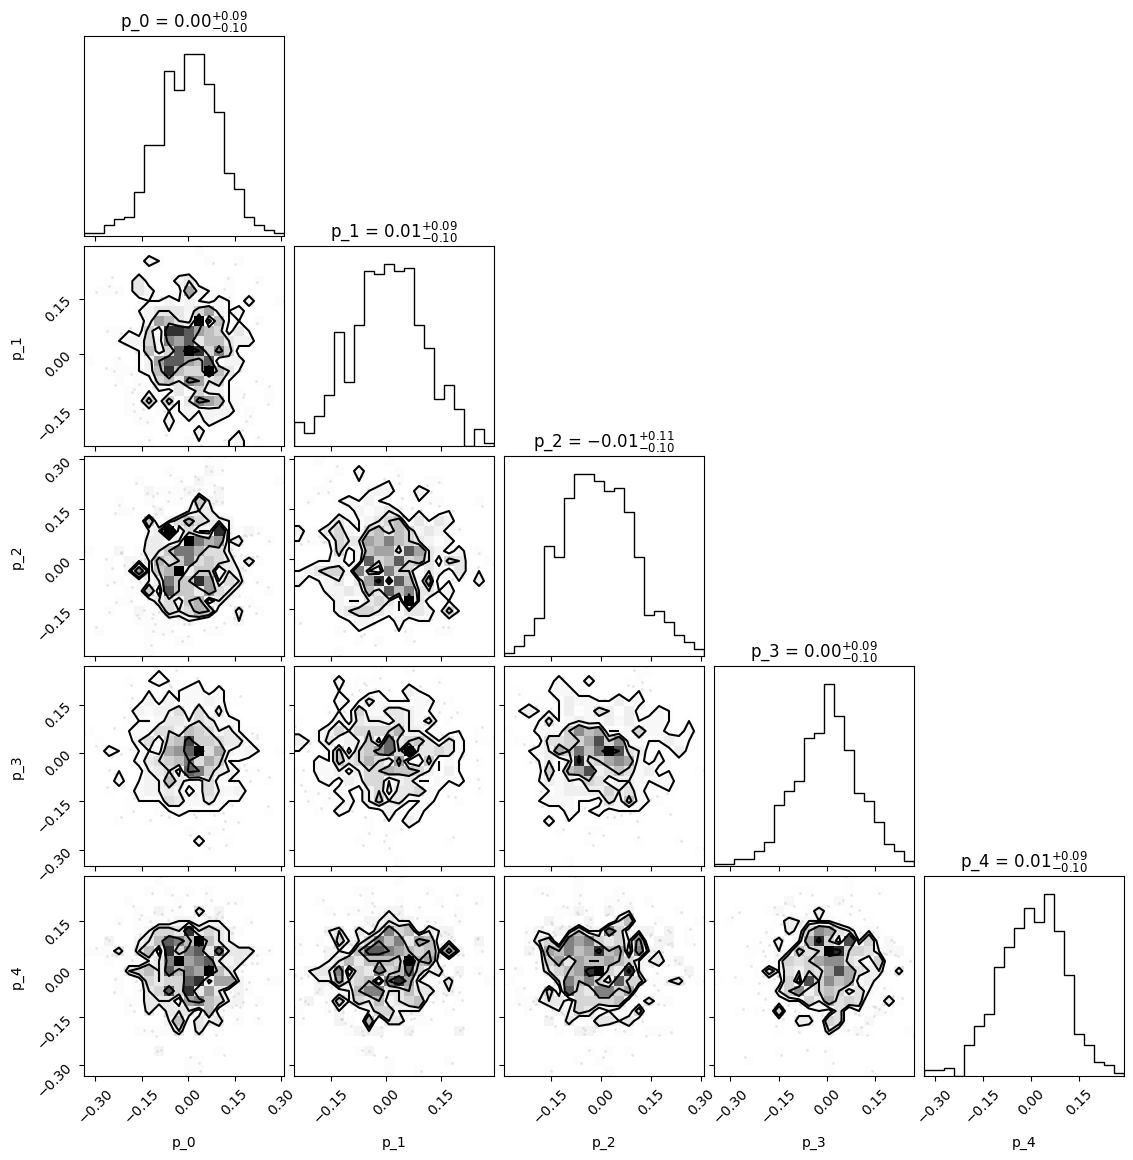

In [44]:
p_samples = posterior_samples['p']
mean_p = jnp.mean(p_samples, axis=0)

print("MCMC Finished!")
print(f"Recovered Mean Perturbation Parameters: {mean_p}")

labels = [f"p_{i}" for i in range(N_MODES)]
fig = corner.corner(
    np.array(p_samples), 
    labels=labels, 
    show_titles=True, 
    title_kwargs={"fontsize": 12}
)
plt.show()

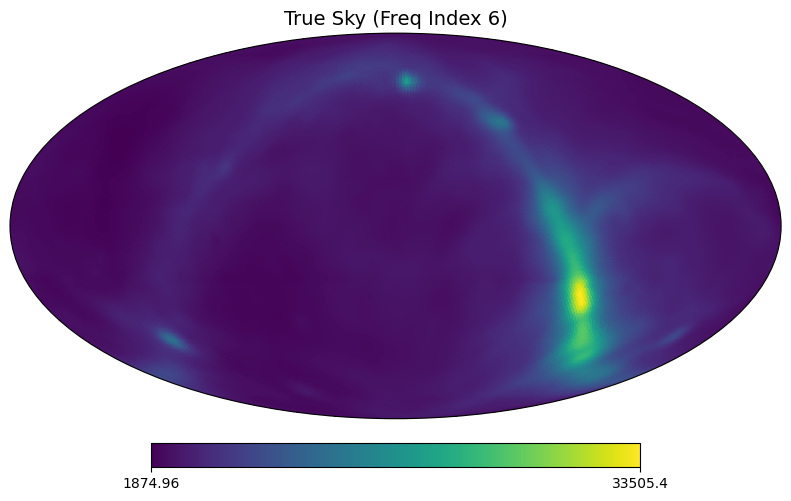

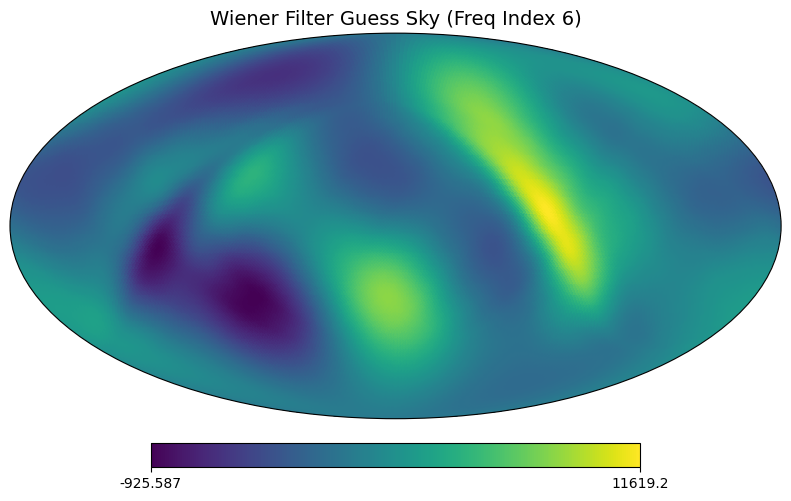

In [45]:
# Unpack the 1D Wiener filter estimate back into (N_FREQS, L, M)
sky_guess_alm = s2fft_unravel(m_wiener, lmax)

# Pick the first frequency in our current simulated batch
f_idx = 0 

# Inverse SHT for the True Sky
original_skymap_0 = s2fft.inverse_jax(
    true_sky_alm[f_idx], L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True
).real

# Inverse SHT for the Guessed Sky
guess_skymap_0 = s2fft.inverse_jax(
    sky_guess_alm[f_idx], L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True
).real

# Plot True Sky
hp.projview(original_skymap_0, title=f"True Sky (Freq Index {FREQ_START + f_idx})")
plt.show()

# Plot Wiener Filter Guess (Will look slightly distorted now—which is correct!)
hp.projview(guess_skymap_0, title=f"Wiener Filter Guess Sky (Freq Index {FREQ_START + f_idx})")
plt.show()

In [46]:
original_skymap_0 = np.asarray(original_skymap_0, dtype=np.float64)
power_spectrum_orig = hp.sphtfunc.anafast(original_skymap_0)
power_spectrum_guess = hp.sphtfunc.anafast(np.asarray(guess_skymap_0, dtype=np.float64))

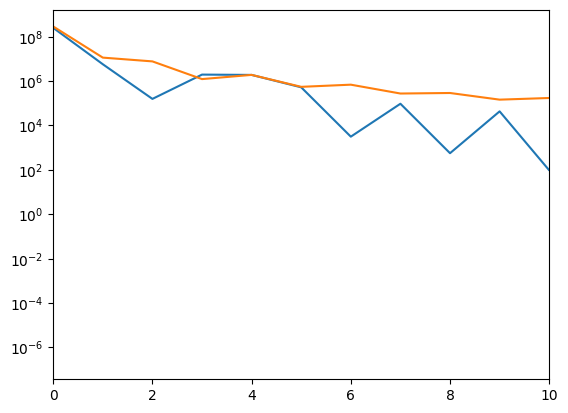

In [47]:
plt.figure()
plt.semilogy(power_spectrum_guess)
plt.semilogy(power_spectrum_orig)
plt.xlim(0, 10)
plt.show()

||y_true||        : 452732.83109195135
||y_guess_best||  : 452727.3628316718
rel err            : 0.04732236396561906


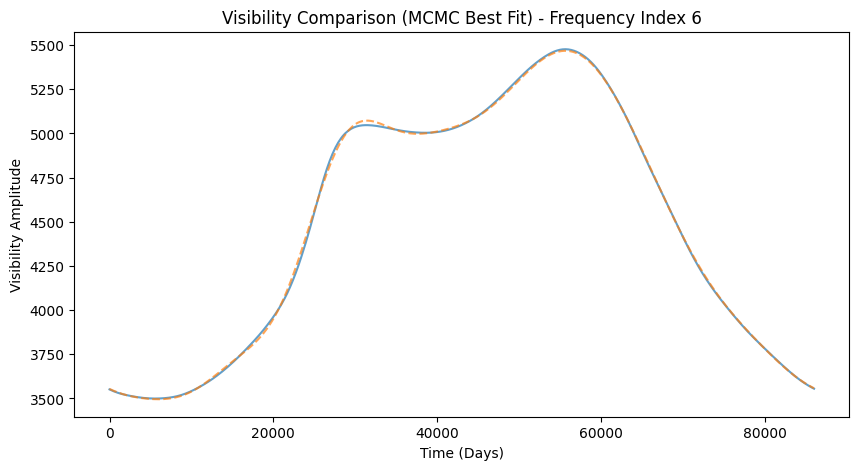

In [48]:
# 1. Reconstruct the "Best Fit" beam by applying learned corrections to the PERTURBED baseline
best_perturbation = jnp.einsum('k, kbf... -> bf...', mean_p, mode_tensor)
best_beam = beam_alms_PERTURBED_transformed + best_perturbation  # <-- CHANGED from beam_alms_transformed

# 2. Generate the visibilities using the Wiener sky and the best-fit corrected MCMC beam
y_guess_best = forward_mcmc(m_wiener_lowpass, best_beam)

# 3. Print the errors
print("||y_true||        :", float(jnp.linalg.norm(y_true)))
print("||y_guess_best||  :", float(jnp.linalg.norm(y_guess_best)))
print("rel err            :", float(jnp.sqrt(jnp.linalg.norm(y_guess_best - y_true)/jnp.linalg.norm(y_true))))

# 4. Reshape to the logical dimensions: (Freq, Time, Beam)
y_true_3d = y_true.reshape(N_FREQS, ntimes, total_beam_num)
y_guess_3d = y_guess_best.reshape(N_FREQS, ntimes, total_beam_num)

# 5. Pick the same frequency to look at
f_idx = 0 

plt.figure(figsize=(10, 5))

# Extract shape (ntimes, total_beam_num)
true_plot = y_true_3d[f_idx] 
guess_plot = y_guess_3d[f_idx]

# Plotting 'true_plot' will draw one line per beam automatically
plt.plot(times_jd - times_jd[0], true_plot[:, 2], alpha=0.7)

# Overlay 'guess_plot' with dashed lines to see how well they match
plt.plot(times_jd - times_jd[0], guess_plot[:, 2], ls="--", alpha=0.7)

plt.title(f"Visibility Comparison (MCMC Best Fit) - Frequency Index {FREQ_START + f_idx}")
plt.xlabel("Time (Days)")
plt.ylabel("Visibility Amplitude")
plt.show()

--- Visualizing MCMC Calibration Success ---


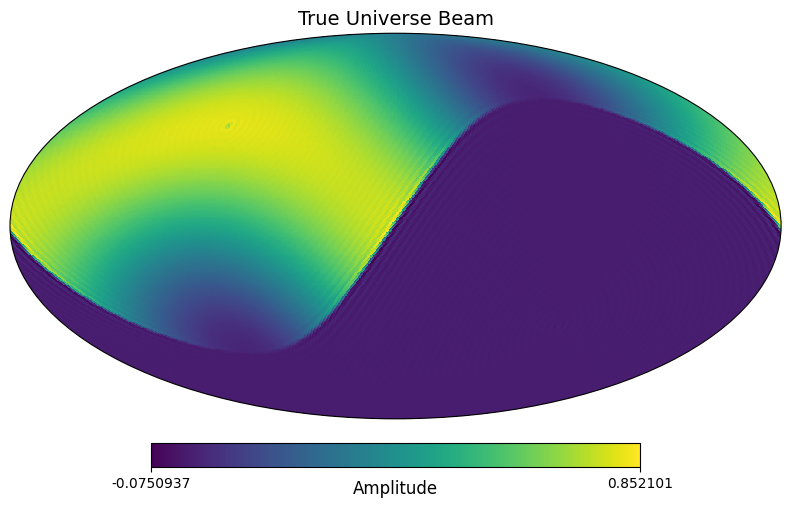

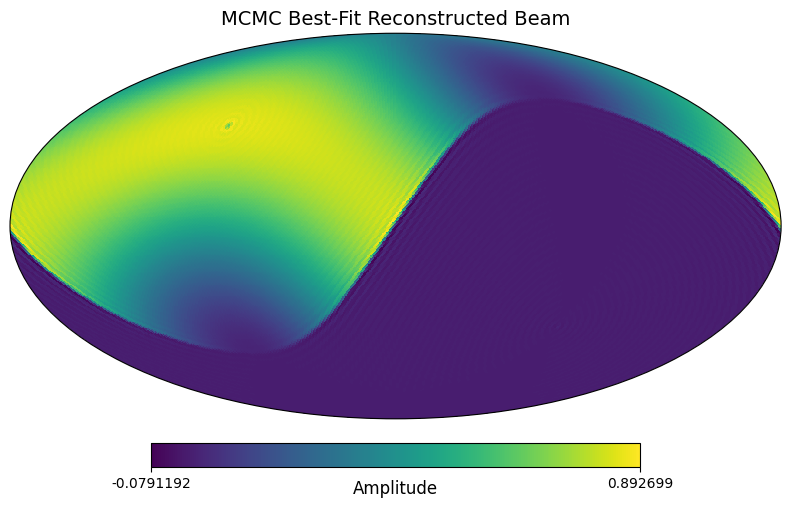

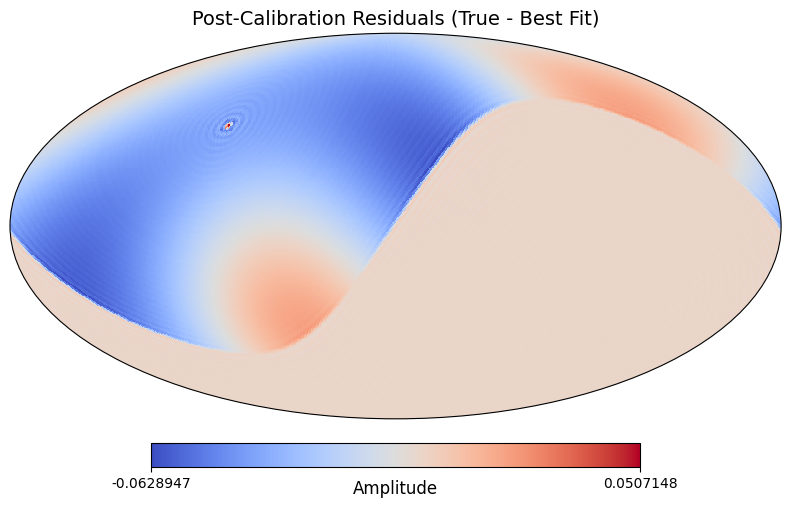

In [49]:
# 1. Select the same pointing and frequency channel to look at
b_idx = 0  
f_idx = 0  

# 2. Extract the True Map IN THE ROTATED SKY FRAME
# We use the rotated ALMs (ensure this variable name matches what you used to make y_true)
true_beam_pixel = s2fft.inverse_jax(
    beam_alms_TRUE_transformed[b_idx, f_idx], 
    L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True
).real
true_map = np.asarray(true_beam_pixel)

# 3. Convert the MCMC Best-Fit Beam ALM back into pixel space via Inverse SHT
best_beam_pixel = s2fft.inverse_jax(
    best_beam[b_idx, f_idx], 
    L=lmax+1, spin=0, nside=nside, sampling="healpix", reality=True
).real
best_fit_map = np.asarray(best_beam_pixel)

# 4. Calculate the Final Residuals (True minus our MCMC corrected beam)
final_residuals = true_map - best_fit_map

# 5. Anchor the colorbar scales globally for an honest comparison
global_vmax = float(max(np.max(true_map), np.max(best_fit_map)))

print(f"--- Visualizing MCMC Calibration Success ---")

# Plot the True Beam
hp.projview(
    true_map, 
    title="True Universe Beam", 
    unit="Amplitude", 
    cbar=True,
    cmap="viridis",
)
plt.show()

# Plot the MCMC Corrected Beam
hp.projview(
    best_fit_map, 
    title="MCMC Best-Fit Reconstructed Beam", 
    unit="Amplitude", 
    cbar=True,
    cmap="viridis",
)
plt.show()

# Plot the Final Calibration Residual Error
# Ideally, this map should look like a sea of flat near-zero color!
res_vmax = float(np.max(np.abs(final_residuals))) if np.max(np.abs(final_residuals)) > 0 else 1.0
hp.projview(
    final_residuals, 
    title="Post-Calibration Residuals (True - Best Fit)", 
    unit="Amplitude", 
    cbar=True,
    cmap="coolwarm",
)
plt.show()

In [50]:
# 1. Gather the arrays (ensuring consistent signs: Model minus True)
pre_res = pert_map - true_map
post_res = best_fit_map - true_map

# 2. Calculate Mean Absolute Error (MAE)
pre_mae = np.mean(np.abs(pre_res))
post_mae = np.mean(np.abs(post_res))

# 3. Calculate Root Mean Square Error (RMSE)
pre_rmse = np.sqrt(np.mean(pre_res**2))
post_rmse = np.sqrt(np.mean(post_res**2))

# 4. Calculate Relative Error against the True Beam RMS
true_rms = np.sqrt(np.mean(true_map**2))
pre_rel = (pre_rmse / true_rms) * 100
post_rel = (post_rmse / true_rms) * 100

# 5. Calculate the Improvement Factor
rmse_improvement = pre_rmse / post_rmse
mae_improvement = pre_mae / post_mae

print("==========================================================")
print("              GLOBAL BEAM ERROR ANALYSIS                  ")
print("==========================================================")
print(f"Metric              | Pre-Calibration | Post-MCMC Calibration")
print(f"--------------------|-----------------|----------------------")
print(f"Mean Absolute Error | {pre_mae:15.2f} | {post_mae:20.2f}")
print(f"Root Mean Square    | {pre_rmse:15.2f} | {post_rmse:20.2f}")
print(f"Relative Sky Error  | {pre_rel:14.2f}% | {post_rel:19.4f}%")
print("----------------------------------------------------------")
print(f"Overall RMSE Improvement Factor: {rmse_improvement:.1f}x reduction in error.")
print("==========================================================")

              GLOBAL BEAM ERROR ANALYSIS                  
Metric              | Pre-Calibration | Post-MCMC Calibration
--------------------|-----------------|----------------------
Mean Absolute Error |            0.01 |                 0.01
Root Mean Square    |            0.02 |                 0.02
Relative Sky Error  |           5.63% |              5.6331%
----------------------------------------------------------
Overall RMSE Improvement Factor: 1.0x reduction in error.


In [39]:
print("Starting Sanity Check MCMC (Using TRUE Sky)...")

# We flatten the true universe to bypass the Wiener filter entirely
cheat_sky_flat = s2fft_ravel(true_sky_alm)

mcmc.run(
    jax.random.PRNGKey(42), 
    y_obs=y_true,                              
    base_beam=beam_alms_PERTURBED_transformed, 
    mode_tensor=mode_tensor,                  
    fixed_sky=cheat_sky_flat,    # <-- CHEATING: Handing it the perfect universe
    noise_diag=Ndiag
)

# Fetch the parameters and check the error metrics just like before
mcmc_samples_cheat = mcmc.get_samples()
mean_p_cheat = jnp.mean(mcmc_samples_cheat['p'], axis=0)
print(f"Mean PCA parameters found with True Sky: {mean_p_cheat}")

Starting Sanity Check MCMC (Using TRUE Sky)...


sample: 100%|███████████████████████| 700/700 [01:06<00:00, 10.58it/s, 7 steps of size 8.68e-01. acc. prob=0.89]

Mean PCA parameters found with True Sky: [-0.06389186 -0.02621294 -0.13383526 -0.03068489  0.03646575]
